In [1]:
from icecube import dataclasses, dataio, icetray, simclasses
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import time
import scipy.constants as spc
from icecube.phys_services import I3Calculator
from matplotlib.colors import LogNorm
from scipy.stats import skew 

In [9]:
def energy_reco(filelist):
    '''
    This function is to get the reco properties
    vertex recostruction(santa)
    zenith(santa)
    azimuth(santa)
    '''

    data = []

    for file in filelistCC:
        #print(file)
        infile=dataio.I3File(file)
        while(infile.more()):
            frame = infile.pop_frame()
            if frame.Stop == icetray.I3Frame.Physics:
                if 'Strict_Vertex' in frame:
                    mctree = frame["I3MCTree"]
                    primary = mctree.primaries

                    daughter = dataclasses.I3MCTree.first_child(mctree, primary[0].id)
                   
                    if daughter.type == 11 or daughter.type == -11:
                        true_energy = primary[0].energy
                    else:
                        tru_energy = (primary[0].energy - daughter.energy) #Hadronic shower
                            
                    reco_energy = frame["graphnet_dynedge_energy_reconstruction_energy_pred"].value
        
                    data.append((true_energy, reco_energy))
                
    return map(np.array, zip(*data)) if data else (np.array([]),) * 2

In [10]:
filelistCC = sorted(glob('/data/user/akatil/electron_neutrino/for_real/dataset_complete/CC_santa/upgrade_genie_level4_queso_*.i3.zst'))
filelistNC = sorted(glob('/data/user/akatil/electron_neutrino/for_real/dataset_complete/NC_santa/upgrade_genie_level4_queso_*.i3.zst'))

filelist = filelistCC+filelistNC

In [11]:
true_energy, reco_energy = energy_reco(filelist)

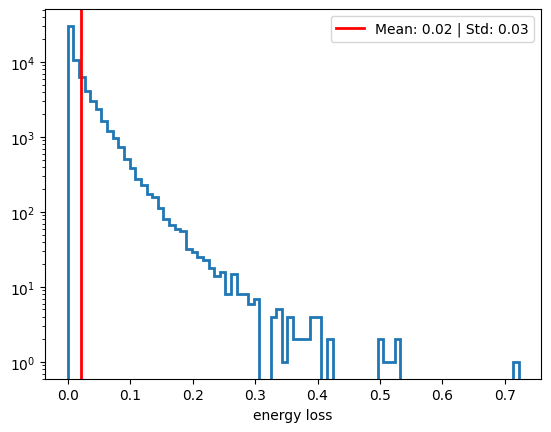

In [12]:
residual = np.log10(reco_energy) - np.log10(true_energy)
loss = np.log(np.cosh(residual))

plt.hist(loss, bins=80, histtype='step', log=True, lw=2)
plt.axvline(np.mean(loss), c='r', lw=2, label = f"Mean: {np.round(np.mean(loss), 2)} | Std: {np.round(np.std(loss), 2)}")
plt.legend()
plt.xlabel('energy loss')
plt.show()